# 02. 一階 ODE — 方向場・変数分離・線形・ロジスティック

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

一階 ODE は最も基本的な形

$$
\frac{dy}{dt} = f(t, y)
$$

です。右辺 $f$ が各点に傾きを与え、解はその **方向場に沿う曲線**。
本章では、解析的に解ける 2 つの型(**変数分離形**・**線形一階**)と、応用の主役 **ロジスティック方程式** を扱います。

## 2. Problem / 3. Intuition

- 銀行口座: 利率が一定なら、残高が多いほど増える額も大きい → $dy/dt = r y$(指数成長)
- 池の藻: 増えるが、池の容量 $K$ に近づくと頭打ち → $dy/dt = r y(1 - y/K)$(ロジスティック)

「変化率が現在の状態に比例する」という素朴な仮定が、指数・ロジスティックという全く違う振る舞いを生みます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 4. Visualization — 方向場と初期条件

同じ方程式でも初期条件で未来が変わります。ロジスティック方程式の方向場に、
複数の初期値からの解を重ねます。**どこから始めても $y=K$ に収束** するのが見どころです。

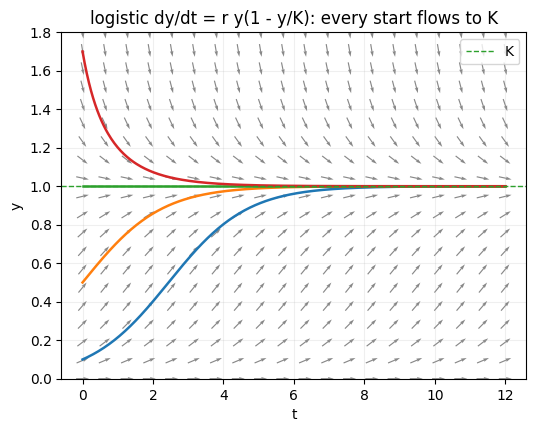

In [3]:
import numpy as np

# Logistic slope field + a fan of initial conditions, all converging to K.
sc = datasets.logistic_scenario()
f = systems.logistic(**sc.params)
ax = plotting.direction_field(f, (0, 12), (0, 1.8), n=20)
t = sc.t
for y0 in sc.y0:
    Y = solvers.rk4(f, [y0], t)
    ax.plot(t, Y[:, 0], lw=1.8)
ax.axhline(sc.params["K"], color="#2ca02c", ls="--", lw=1, label="K")
ax.set_ylim(0, 1.8)
ax.legend()
ax.set_title("logistic dy/dt = r y(1 - y/K): every start flows to K")
plt.show()

## 5. Definition / 6. Computation — 解析的に解ける 2 つの型 (Applied)

### 変数分離形

$\dfrac{dy}{dt} = g(t)\,h(y)$ の形なら、$\dfrac{dy}{h(y)} = g(t)\,dt$ と分離して両辺を積分できます。
最も単純な $dy/dt = r y$ は $y = y_0 e^{rt}$。SymPy で確認します。

In [4]:
import sympy as sp

# Separable: dy/dt = r y  ->  y = y0 e^{r t}.
t, r, y0 = sp.symbols("t r y0", positive=True)
y = sp.Function("y")
sol = sp.dsolve(sp.Eq(y(t).diff(t), r * y(t)), y(t), ics={y(0): y0})
print("dy/dt = r y   =>  ", sol)

dy/dt = r y   =>   Eq(y(t), y0*exp(r*t))


### 線形一階

$\dfrac{dy}{dt} + p(t)\,y = q(t)$ は **積分因子** $\mu(t) = e^{\int p\,dt}$ を掛けると左辺が
$(\mu y)'$ にまとまり、積分で解けます。例として $dy/dt + y = t$ を解きます。

In [5]:
import sympy as sp

# Linear first-order: dy/dt + y = t  (integrating factor mu = e^t).
t = sp.symbols("t")
y = sp.Function("y")
sol = sp.dsolve(sp.Eq(y(t).diff(t) + y(t), t), y(t))
print("dy/dt + y = t  =>  ", sol)

dy/dt + y = t  =>   Eq(y(t), C1*exp(-t) + t - 1)


### ロジスティック方程式

$dy/dt = r y(1 - y/K)$ も変数分離で解け、解は **シグモイド曲線**

$$
y(t) = \frac{K}{1 + \left(\frac{K - y_0}{y_0}\right) e^{-rt}}
$$

になります。解析解と数値解 (RK4) を重ねて一致を確認します。

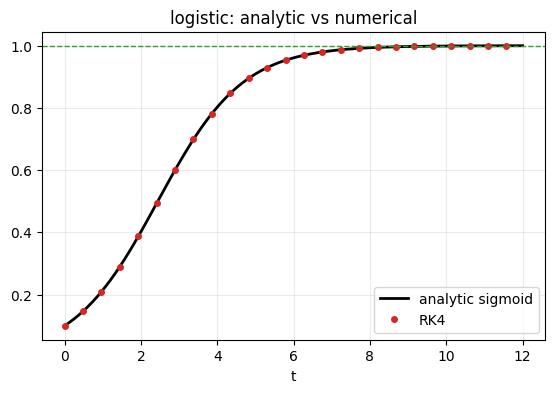

max |analytic - RK4| = 1.0559588647929274e-08


In [6]:
import numpy as np

# Logistic: analytic sigmoid vs RK4.
r, K, y_init = 0.9, 1.0, 0.1
t = np.linspace(0, 12, 200)
analytic = K / (1 + ((K - y_init) / y_init) * np.exp(-r * t))
Y = solvers.rk4(systems.logistic(r, K), [y_init], t)[:, 0]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, analytic, "k-", lw=2, label="analytic sigmoid")
ax.plot(t[::8], Y[::8], "o", color="#d62728", ms=4, label="RK4")
ax.axhline(K, color="#2ca02c", ls="--", lw=1)
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("logistic: analytic vs numerical")
plt.show()
print("max |analytic - RK4| =", np.max(np.abs(analytic - Y)))

### インタラクティブ: 成長率 $r$ を動かす(静的 HTML でも動く)

`ipywidgets` は JupyterLab 専用ですが、**Plotly のスライダーはエクスポートした HTML でも動きます**。
$r$ を大きくするほど収束が速くなり、平衡 $K$ は変わらないことを確かめてください。

In [7]:
import plotly.io as pio
from ode_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = interactive.plotly_logistic_r()
fig.show()

## 7. Invariant — 平衡点

$dy/dt = 0$ となる $y$ が **平衡点(定常解)**。ロジスティックでは $y=0$(不安定)と $y=K$(安定)。
平衡点とその安定性が、長時間後の振る舞いを決めます(04 章で深掘り)。

## 8. Failure Mode — 有限時間爆発

すべての解が永遠に存在するとは限りません。$dy/dt = y^2,\ y(0)=1$ の解は $y = 1/(1-t)$ で、
$t \to 1$ で **発散** します。数値解も $t=1$ 手前で破綻します。

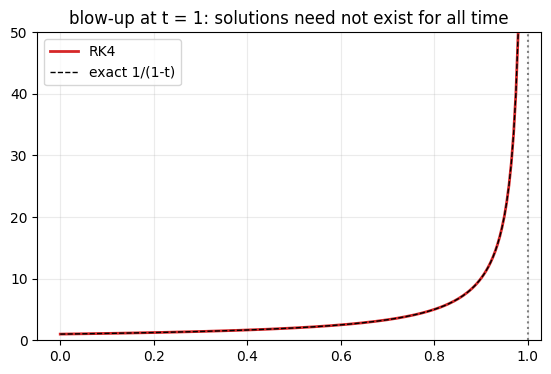

In [8]:
import numpy as np

# Finite-time blow-up: dy/dt = y^2, y(0)=1 -> y = 1/(1-t), diverges at t=1.
f = lambda t, y: y**2
t = np.linspace(0, 0.98, 200)
Y = solvers.rk4(f, [1.0], t)[:, 0]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, Y, color="#d62728", lw=2, label="RK4")
ax.plot(t, 1 / (1 - t), "k--", lw=1, label="exact 1/(1-t)")
ax.axvline(1.0, color="gray", ls=":")
ax.set_ylim(0, 50)
ax.legend()
ax.grid(alpha=0.25)
ax.set_title("blow-up at t = 1: solutions need not exist for all time")
plt.show()

## 9. Application — 放射性崩壊と冷却

- **放射性崩壊** $dy/dt = -k y$: 半減期 $t_{1/2} = \ln 2 / k$。
- **Newton の冷却法則** $dT/dt = -k(T - T_\text{env})$: 物体は環境温度へ指数的に近づく(線形一階の典型)。

## Exercises

1. $dy/dt = -k y$ を変数分離で解き、半減期が初期量によらないことを示せ。
2. $dy/dt + 2y = e^{-t}$ を積分因子で解き、SymPy の結果と一致させよ。
3. ロジスティックで $y_0 > K$ から始めたとき、解が上から $K$ に近づくことを数値で示せ。
4. $dy/dt = \sqrt{|y|},\ y(0)=0$ は解が一意でない(Lipschitz 条件の破れ)。複数解を構成せよ。

## Advanced Notes

- **積分因子の導出**: $(\mu y)' = \mu y' + \mu' y$ が $\mu(y' + p y)$ に一致する条件は $\mu' = p\mu$、すなわち $\mu = e^{\int p}$。
- **完全形と積分因子**: $M\,dt + N\,dy = 0$ が $\partial_y M = \partial_t N$ を満たせば完全形。満たさなくても積分因子で完全形にできる場合がある。
- **Lipschitz と一意性**: $f(t,y)=\sqrt{|y|}$ は $y=0$ で Lipschitz でなく、$y\equiv 0$ と $y=(t/2)^2$ の両方が初期値 0 の解になる。